# Module 20: AdaBoost
## Implementing AdaBoost on a Dataset
## Model Evaluation, Limitations & Use Cases

---

### Learning Objectives
By the end of this notebook, you will be able to:
- Implement AdaBoost using scikit-learn
- Understand the role of weak learners
- Interpret key parameters of AdaBoost
- Evaluate model performance properly
- Identify when AdaBoost should and should not be used


## 1. Libraries and Tools
We first import all required libraries. Each library is chosen intentionally.


In [15]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

## 2. Loading the Dataset
We use the Breast Cancer dataset because it is clean, binary, and well-suited for demonstrating boosting behavior.

In [16]:
X, y = load_breast_cancer(return_X_y = True) 
print("Feature matrix shape:", X.shape) 
print("Target vector shape:", y.shape) 

Feature matrix shape: (569, 30)
Target vector shape: (569,)


## 3. Train-Test Split
We split the dataset so that evaluation is fair and unbiased.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state =42
)
print("Training samples:", X_train.shape[0]) 
print("Testing samples:", X_test.shape[0])

Training samples: 426
Testing samples: 143


## 4. Baseline Model: Decision Stump
Before boosting, we examine how a single weak learner performs.

In [18]:
stump = DecisionTreeClassifier(max_depth=1, random_state=42) 
stump.fit(X_train, y_train) 
y_pred_stump = stump.predict(X_test) 
print("Decision Stump Accuracy", accuracy_score(y_test, y_pred_stump))

Decision Stump Accuracy 0.8951048951048951


## 5. Building AdaBoost Model
Now we boost the weak learner using AdaBoost.

In [19]:
#Building AdaBoost Model 
base_learner = DecisionTreeClassifier(max_depth = 1, random_state=42)
ada = AdaBoostClassifier(
    estimator = base_learner, n_estimators=20, learning_rate = 0.3, random_state=42
)
ada.fit(X_train, y_train) 

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,20
,learning_rate,0.3
,algorithm,'deprecated'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


**AdaBoostClassifier**

class sklearn.ensemble.AdaBoostClassifier(estimator=None, *, n_estimators=50, learning_rate=1.0, random_state=None)

**Parameters:**
* estimator: object, default=None

The base estimator from which the boosted ensemble is built. Support for sample weighting is required, as well as proper classes_ and n_classes_ attributes. If None, then the base estimator is DecisionTreeClassifier initialized with max_depth=1.

* n_estimatorsint, default=50

The maximum number of estimators at which boosting is terminated. In case of perfect fit, the learning procedure is stopped early. Values must be in the range [1, inf).

* learning_rate: float, default=1.0

Weight applied to each classifier at each boosting iteration. A higher learning rate increases the contribution of each classifier. There is a trade-off between the learning_rate and n_estimators parameters. Values must be in the range (0.0, inf).

* random_state: int, RandomState instance or None, default=None

Controls the random seed given at each estimator at each boosting iteration. Thus, it is only used when estimator exposes a random_state. Pass an int for reproducible output across multiple function calls

## 6. Predictions
AdaBoost makes predictions using a weighted vote of weak learners.

In [20]:
# Precision 
y_pred_ada = ada.predict(X_test) 
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))

AdaBoost Accuracy: 0.965034965034965


## 7. Detailed Evaluation
Accuracy alone is not enough. We use additional metrics.

In [21]:
print(classification_report(y_test, y_pred_ada)) 
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ada)) 

              precision    recall  f1-score   support

           0       0.96      0.94      0.95        54
           1       0.97      0.98      0.97        89

    accuracy                           0.97       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143

Confusion Matrix:
 [[51  3]
 [ 2 87]]


## 8. Effect of Number of Estimators
We now observe how the number of weak learners affects performance.

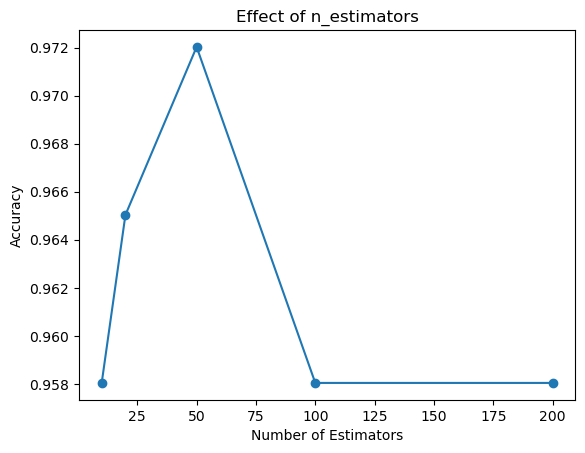

In [22]:
#Effect of Number of Estimators 
estimators = [10, 20 , 50, 100, 200] 
accs = [] 
for n in estimators: 
    model = AdaBoostClassifier(
        estimator = base_learner, 
        n_estimators = n, 
        learning_rate = 0.3, 
        random_state = 42
    )
    model.fit(X_train, y_train) 
    accs.append(accuracy_score(y_test, model.predict(X_test))) 
plt.plot(estimators, accs, marker='o') 
plt.xlabel("Number of Estimators") 
plt.ylabel("Accuracy") 
plt.title("Effect of n_estimators") 
plt.show() 

## 9. Effect of Learning Rate
Learning rate controls how strongly each learner contributes.

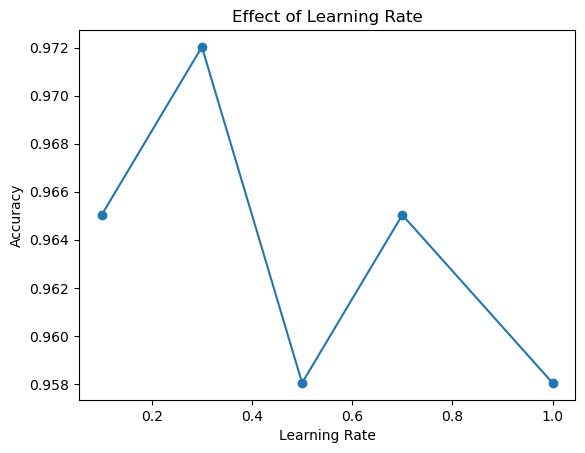

In [23]:
# Effect of Learning Rate 
rates = [0.1, 0.3, 0.5, 0.7, 1.0] 
accs_lr = [] 
for lr in rates:
    model = AdaBoostClassifier(
        estimator = base_learner, 
        n_estimators=50, 
        learning_rate = lr, 
        random_state = 42
    )
    model.fit(X_train, y_train) 
    accs_lr.append(accuracy_score(y_test, model.predict(X_test)))
plt.plot(rates, accs_lr, marker = 'o') 
plt.xlabel("Learning Rate") 
plt.ylabel("Accuracy") 
plt.title("Effect of Learning Rate") 
plt.show()

## 10. GridSearchCV (Optional)
We can try to find the optimal parameters through GridSearchCV here.


In [24]:
from sklearn.model_selection import GridSearchCV

# Parameter grid for AdaBoost
param_grid = {
    'n_estimators': [20, 50, 100, 200],
    'learning_rate': [0.1, 0.3, 0.5, 0.7, 1.0],
    'estimator__max_depth': [1, 2]
}

# GridSearchCV setup
grid = GridSearchCV(
    estimator=AdaBoostClassifier(
        estimator=base_learner,
        random_state=42
    ),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

# Run grid search
grid.fit(X_train, y_train)

# Best model evaluation
best_model = grid.best_estimator_
y_pred_grid = best_model.predict(X_test)

print("Best Parameters Found:")
print(grid.best_params_)
print("\nTest Accuracy (GridSearch AdaBoost):",
      accuracy_score(y_test, y_pred_grid))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_grid))

Best Parameters Found:
{'estimator__max_depth': 1, 'learning_rate': 1.0, 'n_estimators': 200}

Test Accuracy (GridSearch AdaBoost): 0.9790209790209791

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        54
           1       0.99      0.98      0.98        89

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



## 11. Limitations and Use Cases
AdaBoost performs well on clean data but struggles with heavy noise and outliers.

### Changes you can try
1. Change max_depth to 3-6 and observe results
2. Combine low learning rate with high estimators
3. Compare AdaBoost with a full decision tree and Random Forest
